# Data Depth and Depth-Based Classification : Practice & Experiments

**Authored by Alexandre Mathias DONNAT, Sr - Télécom Paris**

This notebook follows the practical session on data depth and depth-based classification.

The objectives are:

1. Generate Gaussian datasets from three bivariate normal distributions.
2. Implement the Mahalanobis depth.
3. Implement the random Tukey depth.
4. Implement a maximum depth classifier with 1NN for outsiders.
5. Construct DD-plots.
6. Implement a DD-kNN classifier.
7. Compare classification error rates.
8. Generate data from a multivariate Student-t distribution.
9. Study DD-plots under heavy-tailed distributions.
10. Compare DD-plot classifiers based on Mahalanobis and Tukey depths.

All results are produced in Python using `numpy`, `matplotlib`, and `scikit-learn`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import inv, pinv
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

## 1. Definition of the three Gaussian models

We consider the following bivariate Gaussian distributions:

- **MVN1**:  
  $$\mathcal{N}\left(\begin{pmatrix}0\\0\end{pmatrix}, \begin{pmatrix}1&1\\1&4\end{pmatrix}\right)$$

- **MVN2**:  
  $$\mathcal{N}\left(\begin{pmatrix}2\\2\end{pmatrix}, \begin{pmatrix}1&1\\1&4\end{pmatrix}\right)$$

- **MVN3**:  
  $$\mathcal{N}\left(\begin{pmatrix}2\\2\end{pmatrix}, \begin{pmatrix}4&4\\4&16\end{pmatrix}\right)$$

We first generate 25 observations from each distribution and display them on separate scatter plots.


In [3]:
mu1 = np.array([0, 0])
mu2 = np.array([2, 2])
mu3 = np.array([2, 2])

Sigma1 = np.array([[1, 1],
                   [1, 4]])

Sigma2 = np.array([[1, 1],
                   [1, 4]])

Sigma3 = np.array([[4, 4],
                   [4, 16]])

n_small = 25

X1 = np.random.multivariate_normal(mu1, Sigma1, size=n_small)
X2 = np.random.multivariate_normal(mu2, Sigma2, size=n_small)
X3 = np.random.multivariate_normal(mu3, Sigma3, size=n_small)

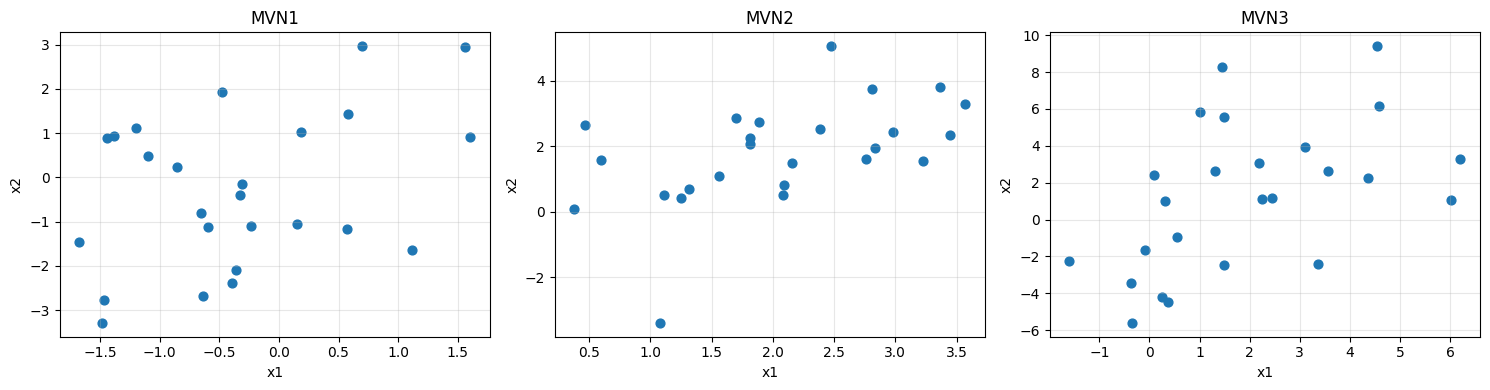

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [(X1, "MVN1"), (X2, "MVN2"), (X3, "MVN3")]

for ax, (X, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], s=40)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Mahalanobis depth

For a point $\mathbf{x}$ and a reference sample $X$, the Mahalanobis depth is defined as

$$
D_M(\mathbf{x}\mid X)
= \frac{1}{1 + (\mathbf{x}-\boldsymbol{\mu}_X)^\top \boldsymbol{\Sigma}_X^{-1}(\mathbf{x}-\boldsymbol{\mu}_X)},
$$

where $\boldsymbol{\mu}_X$ is the empirical mean of the sample and $\boldsymbol{\Sigma}_X$ is its empirical covariance matrix.

This depth is high for central points and decreases as the point moves away from the cloud center in the Mahalanobis geometry.

In [5]:
def depthMah(points, data):
    """
    Compute Mahalanobis depth of each row in `points`
    with respect to reference sample `data`.
    """
    points = np.asarray(points)
    data = np.asarray(data)
    
    mu = np.mean(data, axis=0)
    cov = np.cov(data.T, bias=False)
    
    try:
        cov_inv = inv(cov)
    except np.linalg.LinAlgError:
        cov_inv = pinv(cov)
    
    depths = []
    for x in points:
        diff = x - mu
        md2 = diff.T @ cov_inv @ diff
        depth = 1 / (1 + md2)
        depths.append(depth)
    
    return np.array(depths)

In [6]:
depths_X1_mah = depthMah(X1, X1)
depths_X2_mah = depthMah(X2, X2)
depths_X3_mah = depthMah(X3, X3)

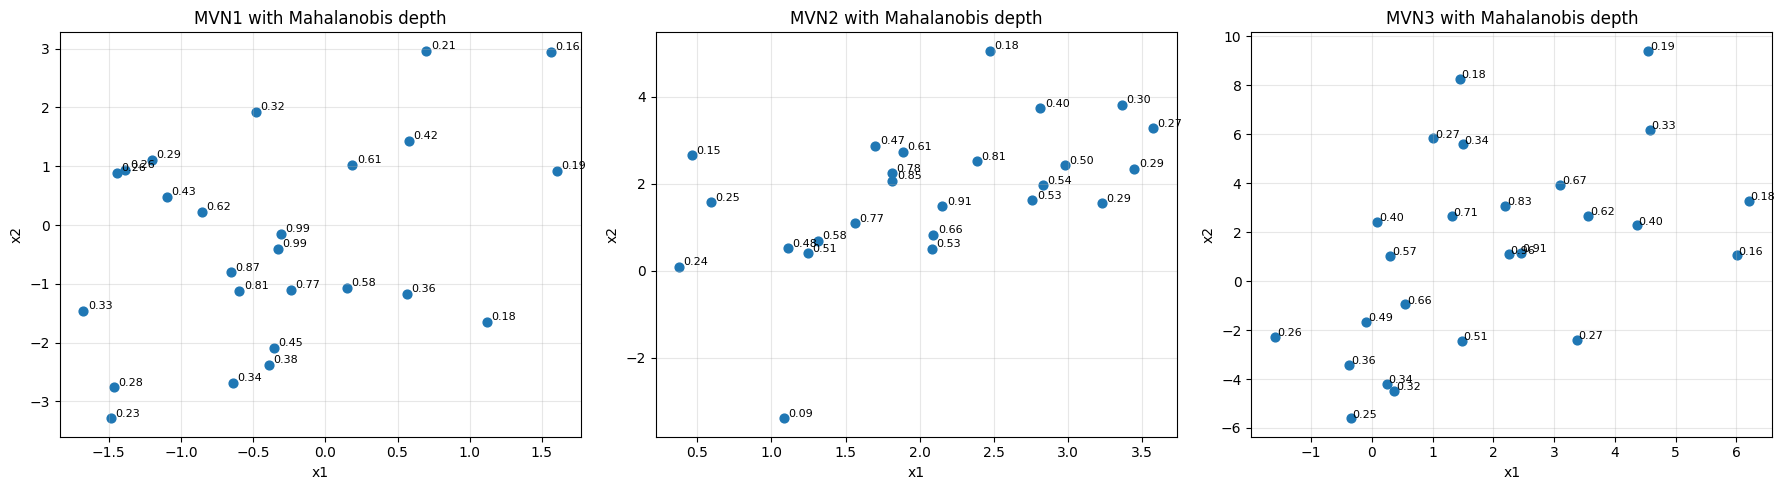

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X, depths, title in zip(
    axes,
    [X1, X2, X3],
    [depths_X1_mah, depths_X2_mah, depths_X3_mah],
    ["MVN1 with Mahalanobis depth", "MVN2 with Mahalanobis depth", "MVN3 with Mahalanobis depth"]
):
    ax.scatter(X[:, 0], X[:, 1], s=40)
    for i, (x, y) in enumerate(X):
        ax.text(x + 0.03, y + 0.03, f"{depths[i]:.2f}", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Random Tukey depth

The Tukey depth of a point is the smallest probability mass in any closed half-space containing that point.

In practice, we approximate it through the **projection property**:
- generate many random directions on the unit sphere,
- project both the sample and the query point onto each direction,
- compute the corresponding univariate depth,
- keep the minimum over all directions.

This approximation is called the **random Tukey depth**.

In [9]:
def univariate_halfspace_depth(z, sample_proj):
    """
    Univariate Tukey/Halfspace depth:
    min(F_n(z), 1 - F_n(z-) ) in empirical form.
    A simple finite-sample approximation is:
    min(P(Y <= z), P(Y >= z)).
    """
    n = len(sample_proj)
    left = np.sum(sample_proj <= z) / n
    right = np.sum(sample_proj >= z) / n
    return min(left, right)

def random_unit_directions(d, ndirs):
    dirs = np.random.normal(size=(ndirs, d))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    return dirs / norms

def depthTuk(points, data, ndirs=100):
    """
    Random Tukey depth approximation.
    """
    points = np.asarray(points)
    data = np.asarray(data)
    
    n, d = data.shape
    dirs = random_unit_directions(d, ndirs)
    
    depths = []
    for x in points:
        min_depth = np.inf
        for u in dirs:
            proj_data = data @ u
            proj_x = x @ u
            depth_u = univariate_halfspace_depth(proj_x, proj_data)
            if depth_u < min_depth:
                min_depth = depth_u
        depths.append(min_depth)
    
    return np.array(depths)

In [10]:
np.random.seed(42)

depths_X1_tuk = depthTuk(X1, X1, ndirs=100)
depths_X2_tuk = depthTuk(X2, X2, ndirs=100)
depths_X3_tuk = depthTuk(X3, X3, ndirs=100)

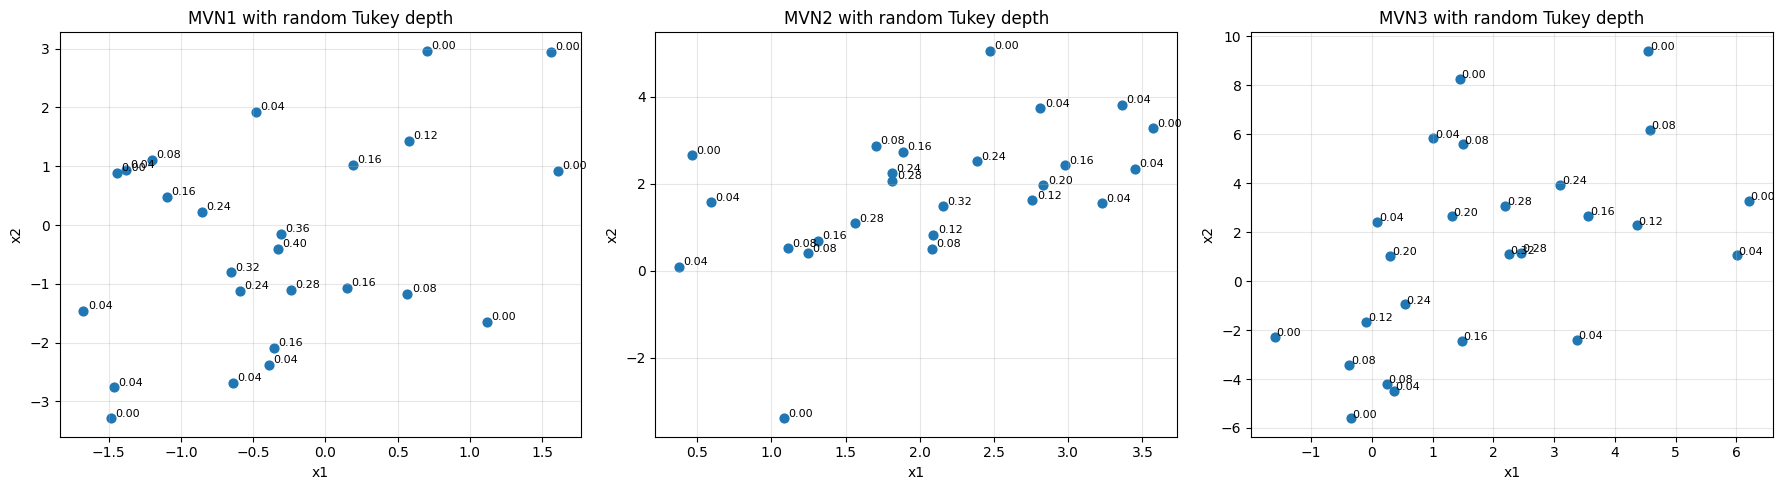

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X, depths, title in zip(
    axes,
    [X1, X2, X3],
    [depths_X1_tuk, depths_X2_tuk, depths_X3_tuk],
    ["MVN1 with random Tukey depth", "MVN2 with random Tukey depth", "MVN3 with random Tukey depth"]
):
    ax.scatter(X[:, 0], X[:, 1], s=40)
    for i, (x, y) in enumerate(X):
        ax.text(x + 0.03, y + 0.03, f"{depths[i]:.2f}", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Maximum depth classifier

The maximum depth classifier assigns a point to the class with respect to which it has the largest depth.

If a point is an outsider, i.e. if its depth is zero with respect to all classes, we classify it using a 1-nearest neighbor rule in the original feature space.

In [13]:
class MaxDepthClassifier:
    def __init__(self, depthName="mahalanobis", ndirs=100):
        self.depthName = depthName
        self.ndirs = ndirs
    
    def _depth(self, points, data):
        if self.depthName.lower() == "mahalanobis":
            return depthMah(points, data)
        elif self.depthName.lower() == "tukey":
            return depthTuk(points, data, ndirs=self.ndirs)
        else:
            raise ValueError("Unknown depth name. Use 'mahalanobis' or 'tukey'.")
    
    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        self.classes_ = np.unique(y)
        self.class_data_ = {c: self.X_train[self.y_train == c] for c in self.classes_}
        self.nn1_ = KNeighborsClassifier(n_neighbors=1)
        self.nn1_.fit(self.X_train, self.y_train)
        return self
    
    def predict(self, X):
        X = np.asarray(X)
        preds = []
        
        for x in X:
            depths = []
            for c in self.classes_:
                d = self._depth(x.reshape(1, -1), self.class_data_[c])[0]
                depths.append(d)
            depths = np.array(depths)
            
            if np.all(depths == 0):
                pred = self.nn1_.predict(x.reshape(1, -1))[0]
            else:
                pred = self.classes_[np.argmax(depths)]
            preds.append(pred)
        
        return np.array(preds)

### Location alternative: MVN1 versus MVN2

We generate a dataset with:
- 250 observations from MVN1,
- 250 observations from MVN2.

We split the data into train and test sets of equal size, display the training set, then fit the maximum depth classifier using the Mahalanobis depth.

In [14]:
np.random.seed(42)

n_class = 250

A = np.random.multivariate_normal(mu1, Sigma1, size=n_class)
B = np.random.multivariate_normal(mu2, Sigma2, size=n_class)

X_loc = np.vstack([A, B])
y_loc = np.array([0]*n_class + [1]*n_class)

X_train_loc, X_test_loc, y_train_loc, y_test_loc = train_test_split(
    X_loc, y_loc, test_size=0.5, random_state=42, stratify=y_loc
)

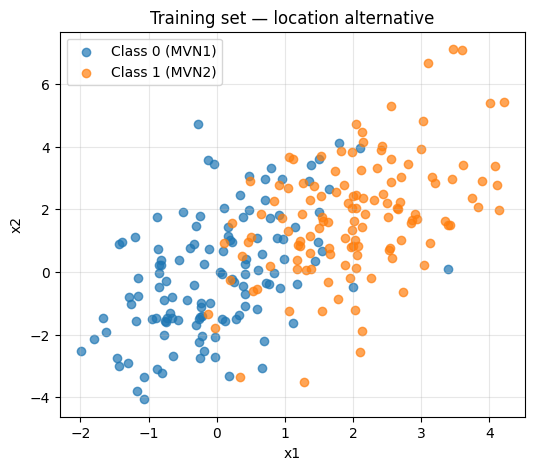

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(X_train_loc[y_train_loc == 0, 0], X_train_loc[y_train_loc == 0, 1], label="Class 0 (MVN1)", alpha=0.7)
plt.scatter(X_train_loc[y_train_loc == 1, 0], X_train_loc[y_train_loc == 1, 1], label="Class 1 (MVN2)", alpha=0.7)
plt.title("Training set — location alternative")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
md_clf_loc = MaxDepthClassifier(depthName="mahalanobis")
md_clf_loc.fit(X_train_loc, y_train_loc)

y_pred_loc = md_clf_loc.predict(X_test_loc)
err_loc = 1 - accuracy_score(y_test_loc, y_pred_loc)

print(f"Maximum depth classifier error rate (Mahalanobis, location alternative): {err_loc:.4f}")

Maximum depth classifier error rate (Mahalanobis, location alternative): 0.1520


## 5. DD-plots

For a two-class problem, the DD-plot maps each point $x$ to

$$
\big(D(x \mid \text{Class 1}),\; D(x \mid \text{Class 2})\big)
$$

This transforms the original multivariate classification problem into a two-dimensional representation in depth space.

In [17]:
def dd_plot_coordinates(X, class0_data, class1_data, depthName="mahalanobis", ndirs=100):
    if depthName.lower() == "mahalanobis":
        d0 = depthMah(X, class0_data)
        d1 = depthMah(X, class1_data)
    elif depthName.lower() == "tukey":
        d0 = depthTuk(X, class0_data, ndirs=ndirs)
        d1 = depthTuk(X, class1_data, ndirs=ndirs)
    else:
        raise ValueError("Unknown depth")
    return d0, d1

### 5(a) DD-plot for MVN1 versus MVN2

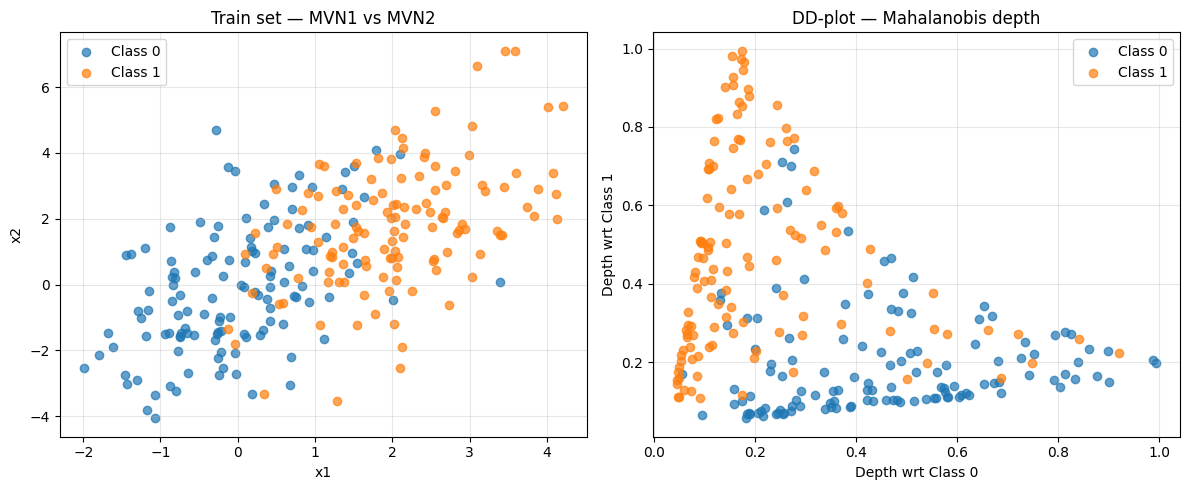

In [18]:
class0_loc = X_train_loc[y_train_loc == 0]
class1_loc = X_train_loc[y_train_loc == 1]

d0_loc, d1_loc = dd_plot_coordinates(X_train_loc, class0_loc, class1_loc, depthName="mahalanobis")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(class0_loc[:, 0], class0_loc[:, 1], label="Class 0", alpha=0.7)
axes[0].scatter(class1_loc[:, 0], class1_loc[:, 1], label="Class 1", alpha=0.7)
axes[0].set_title("Train set — MVN1 vs MVN2")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(d0_loc[y_train_loc == 0], d1_loc[y_train_loc == 0], label="Class 0", alpha=0.7)
axes[1].scatter(d0_loc[y_train_loc == 1], d1_loc[y_train_loc == 1], label="Class 1", alpha=0.7)
axes[1].set_title("DD-plot — Mahalanobis depth")
axes[1].set_xlabel("Depth wrt Class 0")
axes[1].set_ylabel("Depth wrt Class 1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5(b) DD-plot for MVN1 versus MVN3

We now consider a location-scale alternative:
- Class 0: 250 points from MVN1
- Class 1: 250 points from MVN3

In [19]:
np.random.seed(42)

C = np.random.multivariate_normal(mu1, Sigma1, size=n_class)
D = np.random.multivariate_normal(mu3, Sigma3, size=n_class)

X_ls = np.vstack([C, D])
y_ls = np.array([0]*n_class + [1]*n_class)

X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(
    X_ls, y_ls, test_size=0.5, random_state=42, stratify=y_ls
)

class0_ls = X_train_ls[y_train_ls == 0]
class1_ls = X_train_ls[y_train_ls == 1]

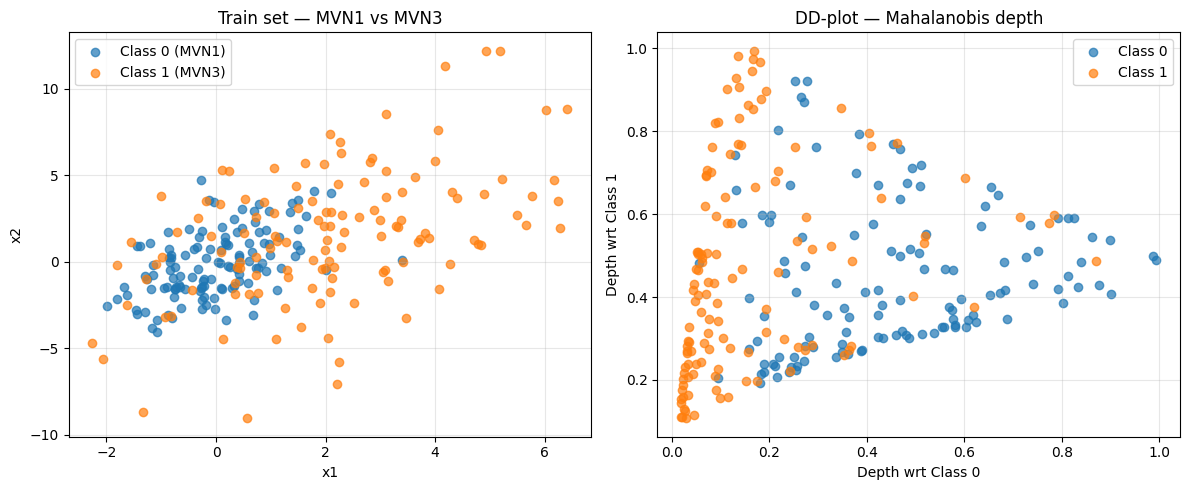

In [20]:
d0_ls, d1_ls = dd_plot_coordinates(X_train_ls, class0_ls, class1_ls, depthName="mahalanobis")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(class0_ls[:, 0], class0_ls[:, 1], label="Class 0 (MVN1)", alpha=0.7)
axes[0].scatter(class1_ls[:, 0], class1_ls[:, 1], label="Class 1 (MVN3)", alpha=0.7)
axes[0].set_title("Train set — MVN1 vs MVN3")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(d0_ls[y_train_ls == 0], d1_ls[y_train_ls == 0], label="Class 0", alpha=0.7)
axes[1].scatter(d0_ls[y_train_ls == 1], d1_ls[y_train_ls == 1], label="Class 1", alpha=0.7)
axes[1].set_title("DD-plot — Mahalanobis depth")
axes[1].set_xlabel("Depth wrt Class 0")
axes[1].set_ylabel("Depth wrt Class 1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. DD-kNN classifier

The DD-kNN classifier first maps the observations into DD-space, then applies a k-nearest neighbors classifier in this transformed space.

As before, if a point is an outsider, we classify it using a 1NN classifier in the original space.

In [21]:
class DDkNNClassifier:
    def __init__(self, depthName="mahalanobis", ndirs=100, k=11):
        self.depthName = depthName
        self.ndirs = ndirs
        self.k = k
    
    def _depth_pair(self, X):
        return np.column_stack(
            dd_plot_coordinates(
                X,
                self.class_data_[self.classes_[0]],
                self.class_data_[self.classes_[1]],
                depthName=self.depthName,
                ndirs=self.ndirs
            )
        )
    
    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        self.classes_ = np.unique(y)
        self.class_data_ = {c: self.X_train[self.y_train == c] for c in self.classes_}
        
        self.DD_train_ = self._depth_pair(self.X_train)
        
        self.knn_dd_ = KNeighborsClassifier(n_neighbors=self.k)
        self.knn_dd_.fit(self.DD_train_, self.y_train)
        
        self.nn1_ = KNeighborsClassifier(n_neighbors=1)
        self.nn1_.fit(self.X_train, self.y_train)
        return self
    
    def predict(self, X):
        X = np.asarray(X)
        DD_test = self._depth_pair(X)
        
        preds = []
        for i in range(len(X)):
            if np.all(DD_test[i] == 0):
                pred = self.nn1_.predict(X[i].reshape(1, -1))[0]
            else:
                pred = self.knn_dd_.predict(DD_test[i].reshape(1, -1))[0]
            preds.append(pred)
        
        return np.array(preds)

### DD-kNN on the MVN1 versus MVN3 dataset

In [22]:
ddknn_clf = DDkNNClassifier(depthName="mahalanobis", k=11)
ddknn_clf.fit(X_train_ls, y_train_ls)

y_pred_ddknn = ddknn_clf.predict(X_test_ls)
err_ddknn = 1 - accuracy_score(y_test_ls, y_pred_ddknn)

print(f"DD-kNN classifier error rate (Mahalanobis, MVN1 vs MVN3): {err_ddknn:.4f}")

DD-kNN classifier error rate (Mahalanobis, MVN1 vs MVN3): 0.1760


## 7. Maximum depth classifier on the MVN1 versus MVN3 dataset

In [23]:
md_clf_ls = MaxDepthClassifier(depthName="mahalanobis")
md_clf_ls.fit(X_train_ls, y_train_ls)

y_pred_md_ls = md_clf_ls.predict(X_test_ls)
err_md_ls = 1 - accuracy_score(y_test_ls, y_pred_md_ls)

print(f"Maximum depth classifier error rate (Mahalanobis, MVN1 vs MVN3): {err_md_ls:.4f}")

Maximum depth classifier error rate (Mahalanobis, MVN1 vs MVN3): 0.2720


## 8. Multivariate Student-t generator

A random vector $X$ follows a multivariate Student-t distribution with $\nu$ degrees of freedom, center $\mu$, and scatter matrix $\Sigma$ if

$$X = \mu + \sqrt{\frac{\nu}{W_\nu}} Z$$

where:
- $W_\nu \sim \chi^2_\nu$,
- $Z \sim \mathcal{N}(0, \Sigma)$,
- $W_\nu$ and $Z$ are independent.

For $\nu=1$, the distribution is the multivariate Cauchy distribution.


In [24]:
def rmvt(mu, Sigma, nu, n):
    """
    Generate n samples from a multivariate Student-t distribution
    with center mu, scatter Sigma, and df nu.
    """
    mu = np.asarray(mu)
    d = len(mu)
    
    Z = np.random.multivariate_normal(mean=np.zeros(d), cov=Sigma, size=n)
    W = np.random.chisquare(df=nu, size=n)
    
    X = mu + Z * np.sqrt(nu / W)[:, None]
    return X

### Bivariate Cauchy samples MVC1 and MVC2

In [25]:
np.random.seed(42)

mvc1_mu = np.array([0, 0])
mvc1_Sigma = np.array([[1, 1],
                       [1, 4]])

mvc2_mu = np.array([1, 1])
mvc2_Sigma = np.array([[1, 1],
                       [1, 4]])

MVC1 = rmvt(mvc1_mu, mvc1_Sigma, nu=1, n=25)
MVC2 = rmvt(mvc2_mu, mvc2_Sigma, nu=1, n=25)

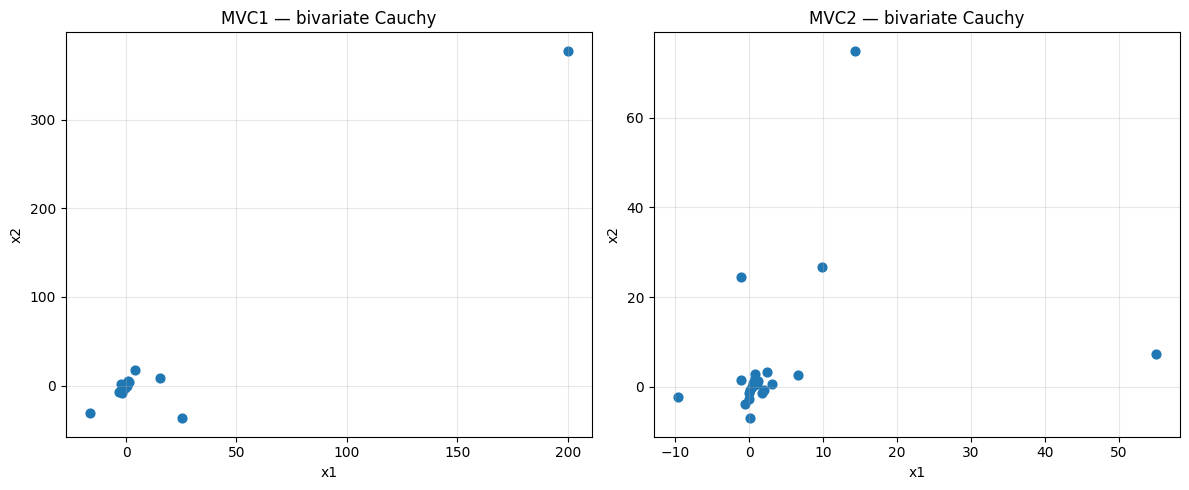

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(MVC1[:, 0], MVC1[:, 1], s=40)
axes[0].set_title("MVC1 — bivariate Cauchy")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(MVC2[:, 0], MVC2[:, 1], s=40)
axes[1].set_title("MVC2 — bivariate Cauchy")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. DD-plots for the Cauchy location alternative

We generate:
- 250 points from MVC1,
- 250 points from MVC2,

then split into train and test sets.

For the training set, we display:
1. the DD-plot based on Mahalanobis depth,
2. the DD-plot based on random Tukey depth with 100 directions.

In [27]:
np.random.seed(42)

n_class = 250

E = rmvt(mvc1_mu, mvc1_Sigma, nu=1, n=n_class)
F = rmvt(mvc2_mu, mvc2_Sigma, nu=1, n=n_class)

X_cauchy = np.vstack([E, F])
y_cauchy = np.array([0]*n_class + [1]*n_class)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cauchy, y_cauchy, test_size=0.5, random_state=42, stratify=y_cauchy
)

class0_c = X_train_c[y_train_c == 0]
class1_c = X_train_c[y_train_c == 1]

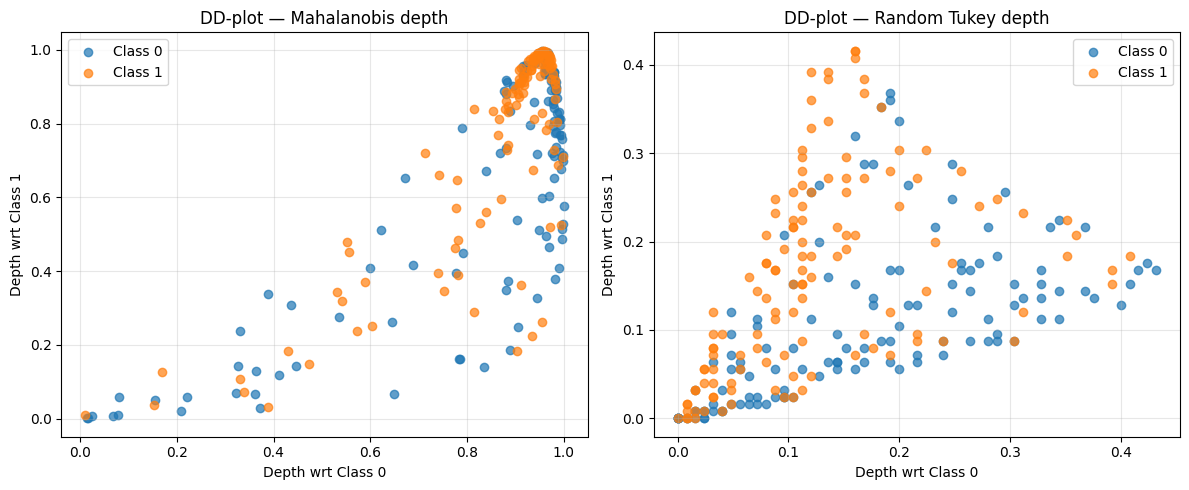

In [28]:
d0_c_mah, d1_c_mah = dd_plot_coordinates(X_train_c, class0_c, class1_c, depthName="mahalanobis")
d0_c_tuk, d1_c_tuk = dd_plot_coordinates(X_train_c, class0_c, class1_c, depthName="tukey", ndirs=100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(d0_c_mah[y_train_c == 0], d1_c_mah[y_train_c == 0], label="Class 0", alpha=0.7)
axes[0].scatter(d0_c_mah[y_train_c == 1], d1_c_mah[y_train_c == 1], label="Class 1", alpha=0.7)
axes[0].set_title("DD-plot — Mahalanobis depth")
axes[0].set_xlabel("Depth wrt Class 0")
axes[0].set_ylabel("Depth wrt Class 1")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(d0_c_tuk[y_train_c == 0], d1_c_tuk[y_train_c == 0], label="Class 0", alpha=0.7)
axes[1].scatter(d0_c_tuk[y_train_c == 1], d1_c_tuk[y_train_c == 1], label="Class 1", alpha=0.7)
axes[1].set_title("DD-plot — Random Tukey depth")
axes[1].set_xlabel("Depth wrt Class 0")
axes[1].set_ylabel("Depth wrt Class 1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Comparison of DD-plot classifiers on the Cauchy dataset

We compare:
- a DD-kNN classifier based on Mahalanobis depth,
- a DD-kNN classifier based on random Tukey depth (100 directions).

The test error rates are reported below.

In [29]:
ddknn_mah_c = DDkNNClassifier(depthName="mahalanobis", k=11)
ddknn_mah_c.fit(X_train_c, y_train_c)
y_pred_mah_c = ddknn_mah_c.predict(X_test_c)
err_mah_c = 1 - accuracy_score(y_test_c, y_pred_mah_c)

ddknn_tuk_c = DDkNNClassifier(depthName="tukey", ndirs=100, k=11)
ddknn_tuk_c.fit(X_train_c, y_train_c)
y_pred_tuk_c = ddknn_tuk_c.predict(X_test_c)
err_tuk_c = 1 - accuracy_score(y_test_c, y_pred_tuk_c)

print(f"DD-kNN error rate with Mahalanobis depth: {err_mah_c:.4f}")
print(f"DD-kNN error rate with random Tukey depth: {err_tuk_c:.4f}")

DD-kNN error rate with Mahalanobis depth: 0.3680
DD-kNN error rate with random Tukey depth: 0.3920


## Interpretation of the results and conclusion

### Gaussian samples and depth values

The three Gaussian samples behave as expected.

- MVN1 is centered around the origin with a moderate dispersion.
- MVN2 has approximately the same covariance structure as MVN1 but is shifted toward the point $$(2,2)$$. This is therefore mainly a location alternative.
- MVN3 is also centered around $$(2,2)$$, but with a much larger covariance matrix, which creates a visibly more dispersed cloud. This is therefore a location-scale alternative.

For the Mahalanobis depth, the most central points have the highest depth values, while peripheral observations have smaller depths. This is coherent with the definition of the Mahalanobis depth, which is based on the empirical mean and covariance matrix of the sample. The values are smooth and continuous, and they reflect well the elliptical geometry of Gaussian clouds.

For the random Tukey depth, the same global behavior is observed: central points tend to have larger depths and extreme points often receive very small depths, sometimes even values close to zero. This is expected because Tukey depth is more demanding geometrically: it measures how deeply a point is embedded in the data cloud from all directions. Since we use only 100 random directions, the computed depth is an approximation, which also explains the more discrete-looking values.

### Maximum depth classifier under the location alternative

For the dataset built from MVN1 versus MVN2, the two classes are shifted relative to each other but still overlap substantially. On the training plot, the separation is visible but far from perfect.

The DD-plot based on Mahalanobis depth is informative in this setting. Points from class 0 tend to have larger depth with respect to class 0 and smaller depth with respect to class 1, while the opposite trend is observed for class 1. This produces a visible structure in DD-space, even if the two groups are not perfectly separated.

This is exactly the type of setting where a depth-based classifier is meaningful: the two distributions have similar shape but different centers, so relative centrality with respect to each class becomes informative.

### DD-plot under the location-scale alternative

For the dataset built from MVN1 versus MVN3, the situation is different. The second class is not only shifted, but also much more spread out. In the original space, class 1 covers a much larger region and overlaps heavily with class 0.

This is reflected in the DD-plot:

- points from the compact class often retain moderate to high depth with respect to class 0,
- points from the dispersed class may have relatively small depth with respect to their own class because the class is much more spread out,
- the two classes are therefore less cleanly separated in DD-space than in the pure location alternative.

This is an important point: a location-scale alternative is harder for simple depth comparison, because the class with larger scatter does not necessarily dominate in terms of depth. Centrality is no longer only about where the cloud is located, but also about how concentrated it is.

### Cauchy samples and the effect of heavy tails

The two bivariate Cauchy samples clearly show the main feature of heavy-tailed distributions: extreme outliers are frequent. In both MVC1 and MVC2, a few observations are extremely far from the bulk of the sample.

This has major consequences.

First, the Mahalanobis depth is based on the empirical mean and covariance matrix, and these quantities are highly sensitive to extreme observations. In a Cauchy setting, this is a structural weakness because the sample covariance may be strongly distorted by a few very large values.

Second, the random Tukey depth is more geometric and in principle more robust to outliers, since it does not rely directly on moments such as the covariance matrix. Its DD-plot is therefore theoretically expected to be more stable under heavy tails.

However, in the present experiment, the DD-plots show that both approaches still lead to substantial overlap between the two classes. The problem is not just robustness: the two Cauchy classes are intrinsically difficult to separate because their tails are very large and their clouds overlap a lot.

### Comparison of the two DD-kNN classifiers on the Cauchy dataset

The reported test error rates are:

- DD-kNN with Mahalanobis depth: $$0.3680$$
- DD-kNN with random Tukey depth: $$0.3920$$

So in this particular run, the Mahalanobis-based DD classifier performs slightly better than the Tukey-based one.

This result should be interpreted carefully.

It would be tempting to conclude that Mahalanobis depth is better even under heavy tails, but that would be too quick. A single run on a random sample is not enough for such a conclusion. The difference here is relatively small, and Tukey depth is approximated with only 100 random directions, which introduces additional variability. Moreover, with Cauchy data, a few extreme points can strongly affect the sample and the resulting classification error.

So the correct reading is the following:

- on this run, Mahalanobis depth gives a slightly lower error;
- but overall, both classifiers perform rather poorly, with error rates close to 40%;
- this confirms that the Cauchy classification problem is much harder than the Gaussian ones.

### General conclusion

This practical session illustrates well the main ideas of depth-based statistics.

- A depth function measures how central a point is with respect to a data cloud.
- The Mahalanobis depth is simple and effective for elliptical data, especially under Gaussian assumptions.
- The Tukey depth is more geometric and potentially more robust, but its approximation through random directions may be unstable when the number of directions is limited.
- The DD-plot is a useful tool because it transforms a multivariate classification problem into a two-dimensional depth representation.
- The maximum depth classifier and the DD-kNN classifier can work well when the classes differ mainly by location.
- When the problem involves scale differences or heavy-tailed distributions, classification becomes much more difficult.